# Initial Dataset preprocessing

In [22]:
import os
import mne
import csv
import pandas as pd
import numpy as np
import json
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import mne_features

In [23]:
parsed_path = "./../EEG_data/parsed/"
summary = "./../EEG_data/parsed/summary.csv"
with open(summary, 'r') as csvfile:
    csvreader = csv.DictReader(csvfile,delimiter =';')
    data_list = []
    for row in csvreader:
        data_list.append(row)
folders = []
for data in data_list:
    if (not data["session_id"] in folders):
        folders.append(data["session_id"])

# paths to the parsed dataset files
p_baseline_intervals = []
p_baseline_markers = []
p_baseline_metadata = []
p_baseline_samples = []
p_main_intervals = []
p_main_markers = []
p_main_metadata = []
p_main_samples = []

for folder in folders:
    p_baseline_intervals.append(parsed_path + folder + "/baseline_intervals.parquet")
    p_baseline_markers.append(parsed_path + folder + "/baseline_markers.parquet")
    p_baseline_metadata.append(parsed_path + folder + "/baseline_metadata.json")
    p_baseline_samples.append(parsed_path + folder + "/baseline_samples.parquet")

    p_main_intervals.append(parsed_path + folder + "/main_intervals.parquet")
    p_main_markers.append(parsed_path + folder + "/main_markers.parquet")
    p_main_metadata.append(parsed_path + folder + "/main_metadata.json")
    p_main_samples.append(parsed_path + folder + "/main_samples.parquet")


In [24]:
# MNE setup
# create raw objects

subject_num = len(folders)
baseline_raw = []
main_raw = []
for i in range (0, subject_num):
    baseline_intervals = pd.read_parquet(p_baseline_intervals[i])
    baseline_markers = pd.read_parquet(p_baseline_markers[i])
    baseline_samples = pd.read_parquet(p_baseline_samples[i])
   
    with open(p_baseline_metadata[i]) as b_meta:
        b_metadata = json.load(b_meta)
    bs_metadata = pd.json_normalize(b_metadata)
    

    main_intervals = pd.read_parquet(p_main_intervals[i])
    main_markers = pd.read_parquet(p_main_markers[i])
    main_samples = pd.read_parquet(p_main_samples[i])

    with open(p_main_metadata[i]) as m_meta:
        m_metadata = json.load(m_meta)
    mn_metadata = pd.json_normalize(m_metadata)

    print(folders[i] + " baseline")
    # baseline raw object
    # data: array, shape (n_channels, n_times)
    bs_channels = bs_metadata.header[0][:-2]
    bs_data = []
    for channel in bs_channels:
        bs_times = baseline_samples[channel].values
        bs_times = np.array(bs_times) * 1e-6
        bs_data.append(bs_times)
    # info
    bs_sfreq = bs_metadata.fs_est.values[0]
    print(bs_sfreq)
    bs_info = mne.create_info(bs_channels, bs_sfreq, 'eeg')
    # create a Raw object
    bs_raw = mne.io.RawArray(bs_data, bs_info, first_samp=0)
    baseline_raw.append(bs_raw)
    print(len(bs_raw))

    print(folders[i] + " main")
    # main raw object
    # data: array, shape (n_channels, n_times)
    mn_channels = mn_metadata.header[0][:-2]
    mn_data = []
    for channel in mn_channels:
        mn_times = main_samples[channel].values
        mn_times = np.array(mn_times) * 1e-6
        mn_data.append(mn_times)
    # info
    mn_sfreq = mn_metadata.fs_est.values[0]
    print(mn_sfreq)
    mn_info = mne.create_info(mn_channels, mn_sfreq, 'eeg')
    # create a Raw object
    mn_raw = mne.io.RawArray(mn_data, mn_info, first_samp=0)
    main_raw.append(mn_raw)
    print(len(mn_raw))


2026-04-04_Lazutkin baseline
118.0552995391705
Creating RawArray with float64 data, n_channels=18, n_times=150233
    Range : 0 ... 150232 =      0.000 ...  1272.556 secs
Ready.
150233
2026-04-04_Lazutkin main
248.43023255813952
Creating RawArray with float64 data, n_channels=18, n_times=22876
    Range : 0 ... 22875 =      0.000 ...    92.078 secs
Ready.
22876
2026-04-04_Vundirov baseline
249.6441605839416
Creating RawArray with float64 data, n_channels=18, n_times=150211
    Range : 0 ... 150210 =      0.000 ...   601.696 secs
Ready.
150211
2026-04-04_Vundirov main
251.9848484848485
Creating RawArray with float64 data, n_channels=18, n_times=17500
    Range : 0 ... 17499 =      0.000 ...    69.445 secs
Ready.
17500
2026-04-10_Aminov baseline
249.88704318936877
Creating RawArray with float64 data, n_channels=18, n_times=150168
    Range : 0 ... 150167 =      0.000 ...   600.940 secs
Ready.
150168
2026-04-10_Aminov main
250.1304347826087
Creating RawArray with float64 data, n_channels=

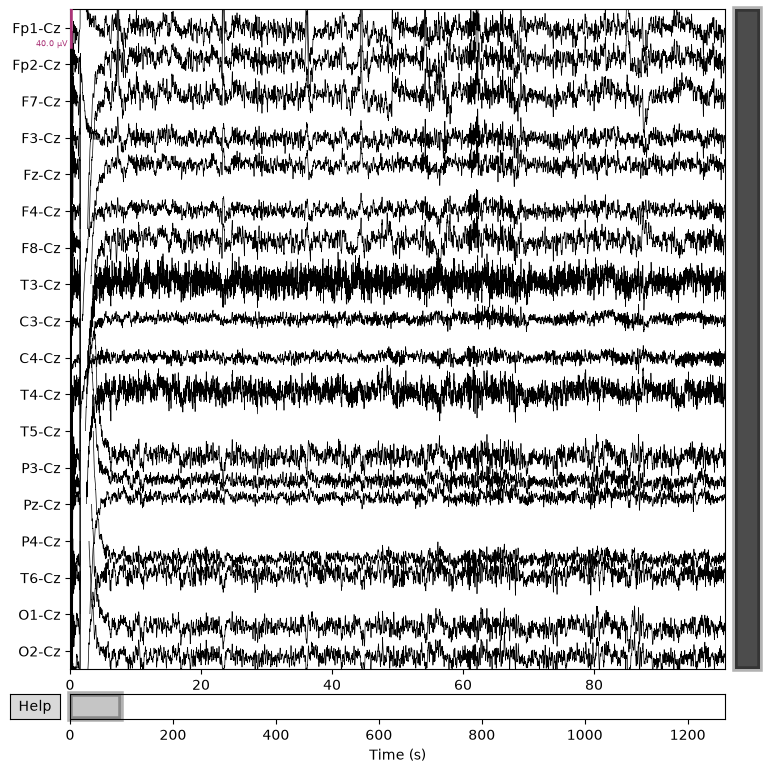

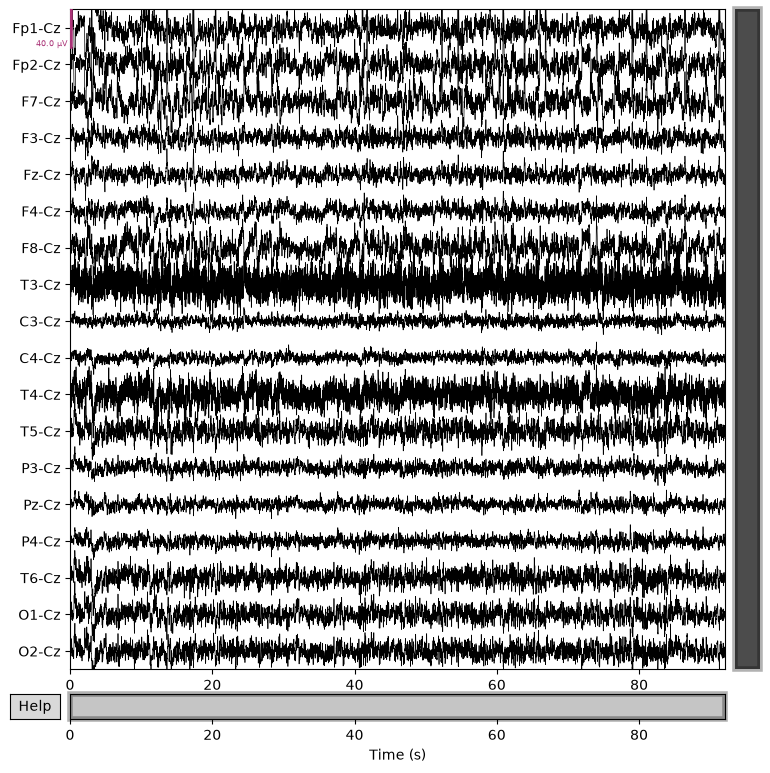

In [26]:
# plots of the raw data for the first two sessions (first is baseline, second is main)
# as you can see, the first baseline contains a huge artifact
baseline_raw[0].plot(duration=100);
main_raw[0].plot(duration=100);

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


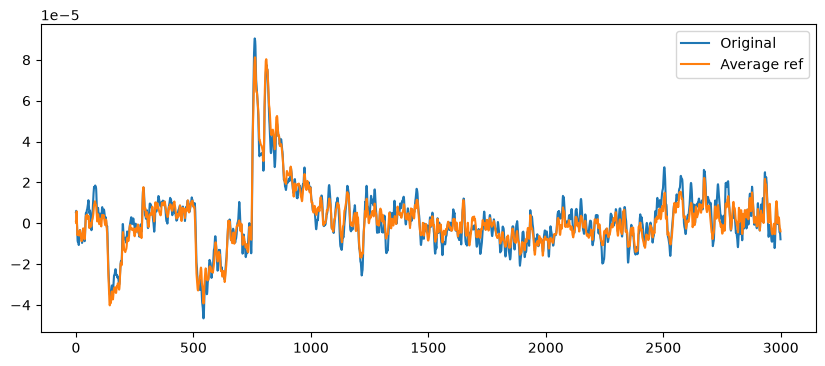

In [27]:
# re-referencing example of the difference (session 2026-04-04_Lazutkin, main, first 3000 samples)
m_1 = main_raw[0].copy()
m_2 = m_1.copy()
m_2.set_eeg_reference(ref_channels='average') 
orig = m_1.get_data()[0]
ref = m_2.get_data()[0]
plt.figure(figsize=(10,4))
plt.plot(orig[:3000], label='Original')
plt.plot(ref[:3000], label='Average ref')
plt.legend()
plt.show()

In [28]:
# full dataset re-referencing
baseline_ref = [raw.copy() for raw in baseline_raw]
main_ref = [raw.copy() for raw in main_raw]
for baseline in baseline_ref:
    baseline.set_eeg_reference(ref_channels='average') 
for main in main_ref:
    main.set_eeg_reference(ref_channels='average')


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
E

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 0.7 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.70
- Lower transition bandwidth: 0.70 Hz (-6 dB cutoff frequency: 0.35 Hz)
- Filter length: 557 samples (4.718 s)



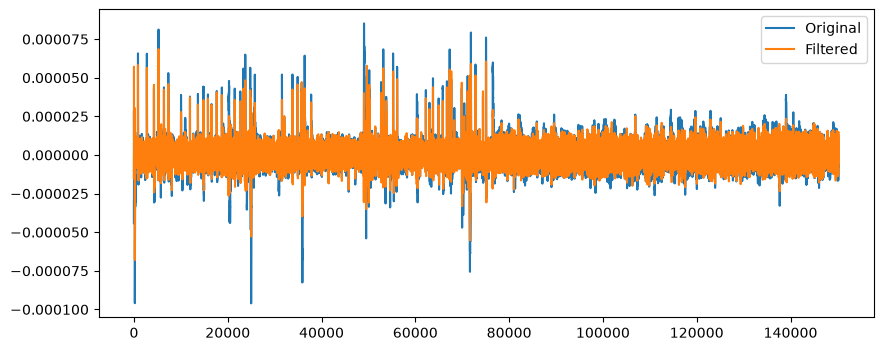

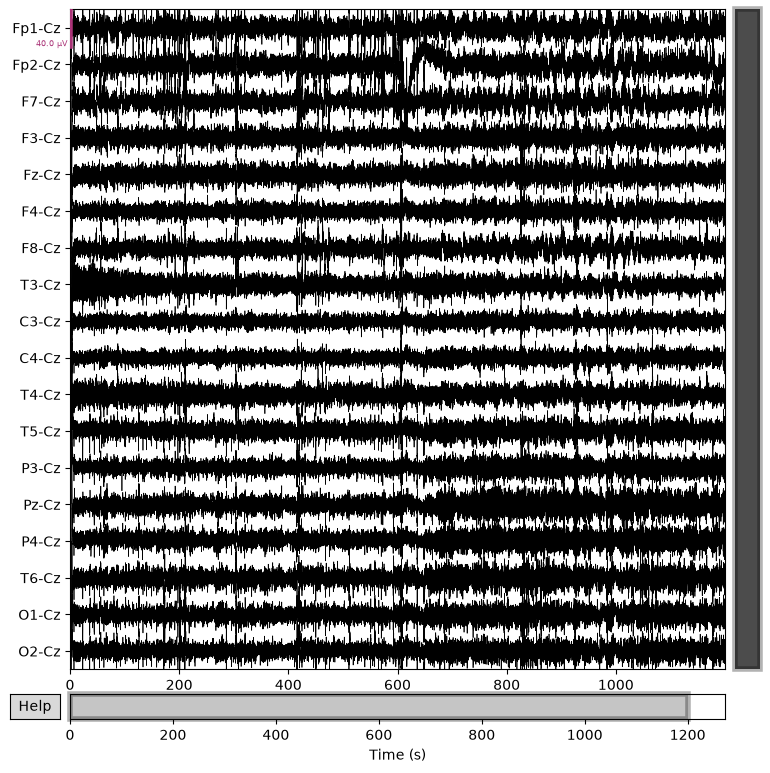

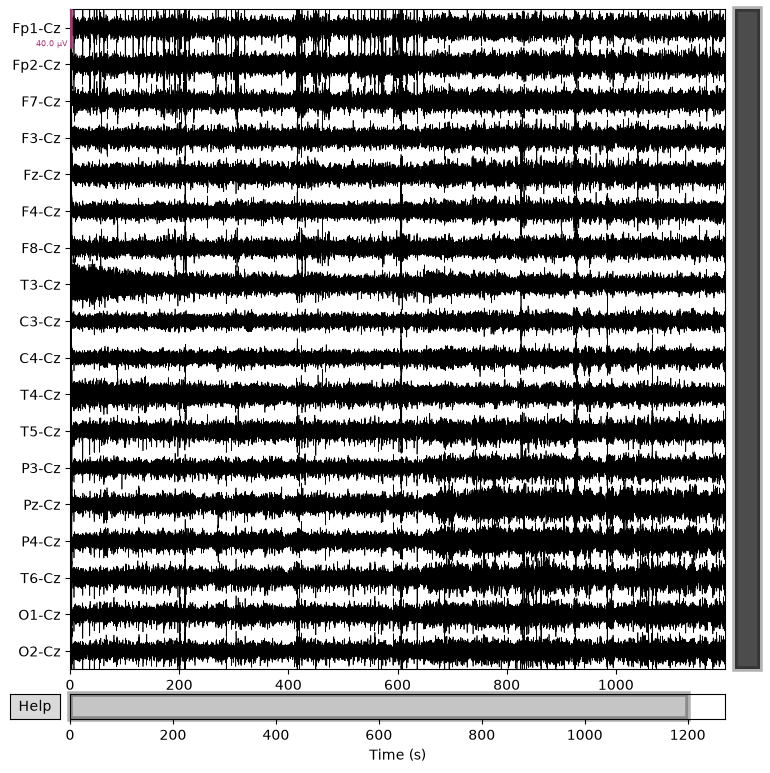

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 0.7 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.70
- Lower transition bandwidth: 0.70 Hz (-6 dB cutoff frequency: 0.35 Hz)
- Filter length: 557 samples (4.718 s)

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 0.7 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.70
- Lower transition bandwidth: 0.70 Hz (-6 dB cutoff frequency: 0.35 Hz)
- Filter length: 1177 samples (4.715 s)

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 0.7 Hz

FIR filter parame

In [46]:
# apply highpass filter (0.7 Hz)
# remove low-frequency drifts 

baseline_hband = [raw.copy() for raw in baseline_ref]
main_hband = [raw.copy() for raw in main_ref]

# example: (session 2026-04-04_Lazutkin, baseline, full time 1200s; 
# first picture is raw, second is filtered)
b_high = baseline_hband[0].copy().filter(l_freq=0.7, h_freq=None)
orig = baseline_hband[0].get_data()[0]
ref = b_high.get_data()[0]
plt.figure(figsize=(10,4))
plt.plot(orig[:], label='Original')
plt.plot(ref[:], label='Filtered')
plt.legend()
plt.show()
fig_orig = baseline_hband[0].copy().plot(
    duration=1200, proj=False, n_channels=len(baseline_hband[0].ch_names), remove_dc=False
);
fig = b_high.plot(
    duration=1200, proj=False, n_channels=len(b_high.ch_names), remove_dc=False
);
fig_orig.subplots_adjust(top=0.9)
fig_orig.suptitle(f"Raw data", size="xx-large", weight="bold")
fig.subplots_adjust(top=0.9)
fig.suptitle(f"High-pass filtered at {0.7} Hz", size="xx-large", weight="bold")

# apply highpass filter on the whole dataset
baseline_hband = [raw.copy().filter(l_freq=0.7, h_freq=None) for raw in baseline_hband]
main_hband = [raw.copy().filter(l_freq=0.7, h_freq=None) for raw in main_hband]

Effective window size : 8.244 (s)
Plotting power spectral density (dB=True).


/Users/fountainer/.pyenv/versions/eeg-to-code/lib/python3.14/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


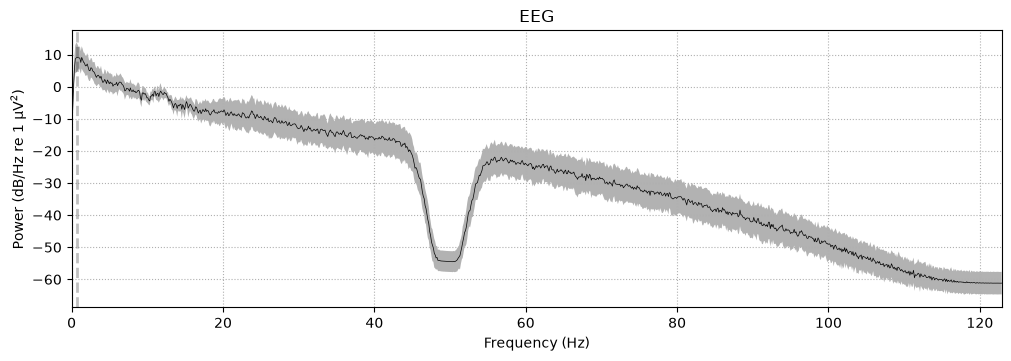

In [115]:
# powerline noise (notch filter)

# as we can see, the signal already has a deep in 50Hz freq, so it seems that the notch filter has already been applied
fig = main_hband[0].compute_psd(fmax=123).plot(
    average=True, amplitude=False, picks="data", exclude="bads"
)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 99 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 99.25
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 99.00 Hz)
- Upper passband edge: 100.75 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 101.00 Hz)
- Filter length: 1649 samples (6.605 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 99 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 99.25
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 99.00 Hz)
- Upper pa

/Users/fountainer/.pyenv/versions/eeg-to-code/lib/python3.14/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


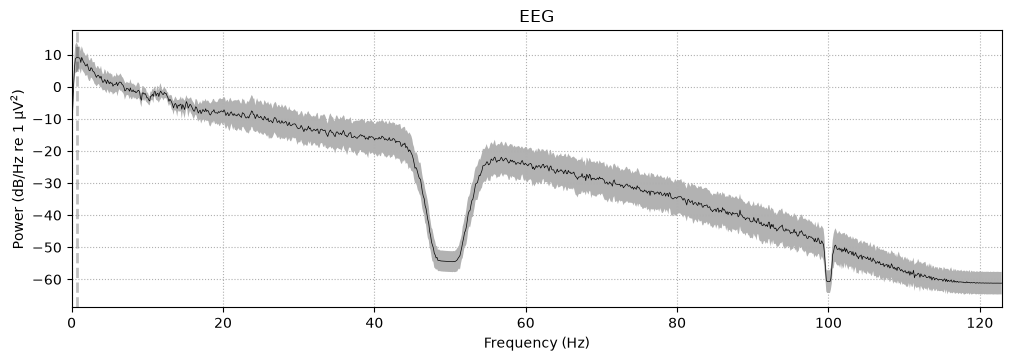

In [152]:
# I additionally apply the notch filter for the first 50Hz harmonic (100Hz)

# I skip the first baseline, since its sampling frequency is too low to use 100Hz


baseline_notch = [baseline_hband[0]] + [raw.copy().notch_filter(freqs=(100), picks=("eeg")) for raw in baseline_hband[1:]]
main_notch = [raw.copy().notch_filter(freqs=(100), picks=("eeg")) for raw in main_hband]

fig = main_notch[0].compute_psd(fmax=123).plot(
    average=True, amplitude=False, picks="data", exclude="bads"
)

# the change seems to be minimal

Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 73 samples (0.294 s)



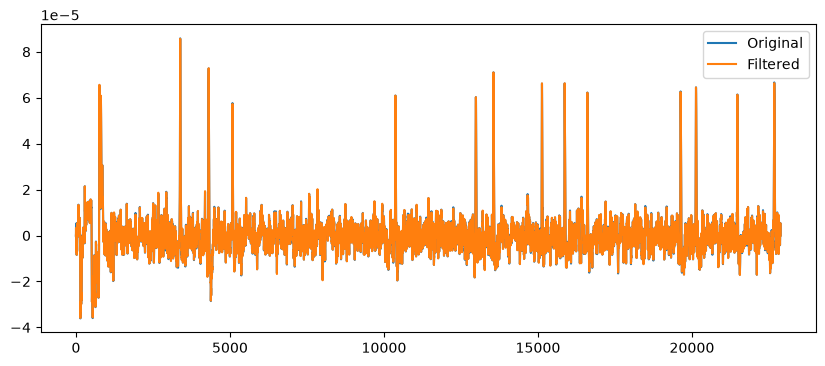

Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 35 samples (0.296 s)

Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 75 samples (0.300 s)

Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 45 Hz

FIR filter param

In [151]:
# apply lowpass filter (50Hz)

baseline_lband = [raw.copy() for raw in baseline_notch]
main_lband = [raw.copy() for raw in main_notch]

# example: (session 2026-04-04_Lazutkin, baseline; 
# first picture is raw, second is filtered)
b_low = main_lband[0].copy().filter(l_freq=None, h_freq=45)
orig = main_lband[0].get_data()[0]
ref = b_low.get_data()[0]
plt.figure(figsize=(10,4))
plt.plot(orig[:], label='Original')
plt.plot(ref[:], label='Filtered')
plt.legend()
plt.show()

# apply highpass filter on the whole dataset
baseline_lband = [raw.copy().filter(l_freq=None, h_freq=45) for raw in baseline_notch]
main_lband = [raw.copy().filter(l_freq=None, h_freq=45) for raw in main_notch]